In [1]:
# Purpose: 

In [2]:
### Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from category_encoders import TargetEncoder
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, LeakyReLU
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import shutil

In [3]:
### Load Data
data = pd.read_csv('dataset_Porter.csv')


In [4]:
### Display first few rows
display(data.head())

,market_id,created_at,actual_delivery_time,store_id,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_partners,total_busy_partners,total_outstanding_orders
0,1.0,2015-02-06 22:24:17,2015-02-06 23:27:16,df263d996281d984952c07998dc54358,american,1.0,4,3441,4,557,1239,33.0,14.0,21.0
1,2.0,2015-02-10 21:49:25,2015-02-10 22:56:29,f0ade77b43923b38237db569b016ba25,mexican,2.0,1,1900,1,1400,1400,1.0,2.0,2.0
2,3.0,2015-01-22 20:39:28,2015-01-22 21:09:09,f0ade77b43923b38237db569b016ba25,NaN,1.0,1,1900,1,1900,1900,1.0,0.0,0.0
3,3.0,2015-02-03 21:21:45,2015-02-03 22:13:00,f0ade77b43923b38237db569b016ba25,NaN,1.0,6,6900,5,600,1800,1.0,1.0,2.0
4,3.0,2015-02-15 02:40:36,2015-02-15 03:20:26,f0ade77b43923b38237db569b016ba25,NaN,1.0,3,3900,3,1100,1600,6.0,6.0,9.0


In [5]:
### Data structure and basic info
display(data.info())
display(data.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 197428 entries, 0 to 197427
Data columns (total 14 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   market_id                 196441 non-null  float64
 1   created_at                197428 non-null  object 
 2   actual_delivery_time      197421 non-null  object 
 3   store_id                  197428 non-null  object 
 4   store_primary_category    192668 non-null  object 
 5   order_protocol            196433 non-null  float64
 6   total_items               197428 non-null  int64  
 7   subtotal                  197428 non-null  int64  
 8   num_distinct_items        197428 non-null  int64  
 9   min_item_price            197428 non-null  int64  
 10  max_item_price            197428 non-null  int64  
 11  total_onshift_partners    181166 non-null  float64
 12  total_busy_partners       181166 non-null  float64
 13  total_outstanding_orders  181166 non-null  f

None

,market_id,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_partners,total_busy_partners,total_outstanding_orders
count,196441.000000,196433.000000,197428.000000,197428.000000,197428.000000,197428.000000,197428.000000,181166.000000,181166.000000,181166.000000
mean,2.978706,2.882352,3.196391,2682.331402,2.670791,686.218470,1159.588630,44.808093,41.739747,58.050065
std,1.524867,1.503771,2.666546,1823.093688,1.630255,522.038648,558.411377,34.526783,32.145733,52.661830
min,1.000000,1.000000,1.000000,0.000000,1.000000,-86.000000,0.000000,-4.000000,-5.000000,-6.000000
25%,2.000000,1.000000,2.000000,1400.000000,1.000000,299.000000,800.000000,17.000000,15.000000,17.000000
50%,3.000000,3.000000,3.000000,2200.000000,2.000000,595.000000,1095.000000,37.000000,34.000000,41.000000
75%,4.000000,4.000000,4.000000,3395.000000,3.000000,949.000000,1395.000000,65.000000,62.000000,85.000000
max,6.000000,7.000000,411.000000,27100.000000,20.000000,14700.000000,14700.000000,171.000000,154.000000,285.000000


In [6]:
### Feature Engineering
# Convert timestamps to datetime format
data['created_at'] = pd.to_datetime(data['created_at'])
data['actual_delivery_time'] = pd.to_datetime(data['actual_delivery_time'])


In [7]:
### Create target column: delivery_time_in_minutes
data['delivery_time_in_minutes'] = (data['actual_delivery_time'] - data['created_at']).dt.total_seconds() / 60

In [8]:
### Extract hour of the day and day of the week
data['order_hour'] = data['created_at'].dt.hour
data['order_day'] = data['created_at'].dt.dayofweek

In [9]:
### Feature interactions
data['order_to_partner_ratio'] = data['total_outstanding_orders'] / (data['total_onshift_partners'] + 1)

In [10]:
data.isna().sum()

market_id                     987
created_at                      0
actual_delivery_time            7
store_id                        0
store_primary_category       4760
order_protocol                995
total_items                     0
subtotal                        0
num_distinct_items              0
min_item_price                  0
max_item_price                  0
total_onshift_partners      16262
total_busy_partners         16262
total_outstanding_orders    16262
delivery_time_in_minutes        7
order_hour                      0
order_day                       0
order_to_partner_ratio      16262
dtype: int64

In [11]:
### Handling null values
data.replace([np.inf, -np.inf], np.nan, inplace=True)
data.dropna(inplace=True)


In [12]:
### Drop unnecessary columns
data.drop(columns=['store_id', 'created_at', 'actual_delivery_time'], inplace=True, errors='ignore')

In [13]:
### Ensure target variable has no missing values
data = data.dropna(subset=['delivery_time_in_minutes'])

In [14]:
### Encoding categorical columns using Target Encoding
encoder = TargetEncoder()
for col in ['store_primary_category', 'market_id', 'order_protocol']:
    data[col] = encoder.fit_transform(data[col], data['delivery_time_in_minutes'])

In [15]:
### Ensure all columns are numeric
print("Columns after encoding:", data.dtypes)


Columns after encoding: market_id                   float64
store_primary_category      float64
order_protocol              float64
total_items                   int64
subtotal                      int64
num_distinct_items            int64
min_item_price                int64
max_item_price                int64
total_onshift_partners      float64
total_busy_partners         float64
total_outstanding_orders    float64
delivery_time_in_minutes    float64
order_hour                    int32
order_day                     int32
order_to_partner_ratio      float64
dtype: object


In [16]:
### Applying Polynomial Features of Degree 2
poly = PolynomialFeatures(degree=2, interaction_only=False, include_bias=False)
X_numeric = data.drop(columns=['delivery_time_in_minutes']).select_dtypes(include=[np.number])
X_poly = poly.fit_transform(X_numeric)
X_poly = pd.DataFrame(X_poly, columns=poly.get_feature_names_out(X_numeric.columns))
X_poly = pd.DataFrame(X_poly, columns=poly.get_feature_names_out(data.drop(columns=['delivery_time_in_minutes']).columns))

In [33]:
# ### Export processed data to Excel
# poly.to_excel("processed_porter_data_poly_00.xlsx", index=False)

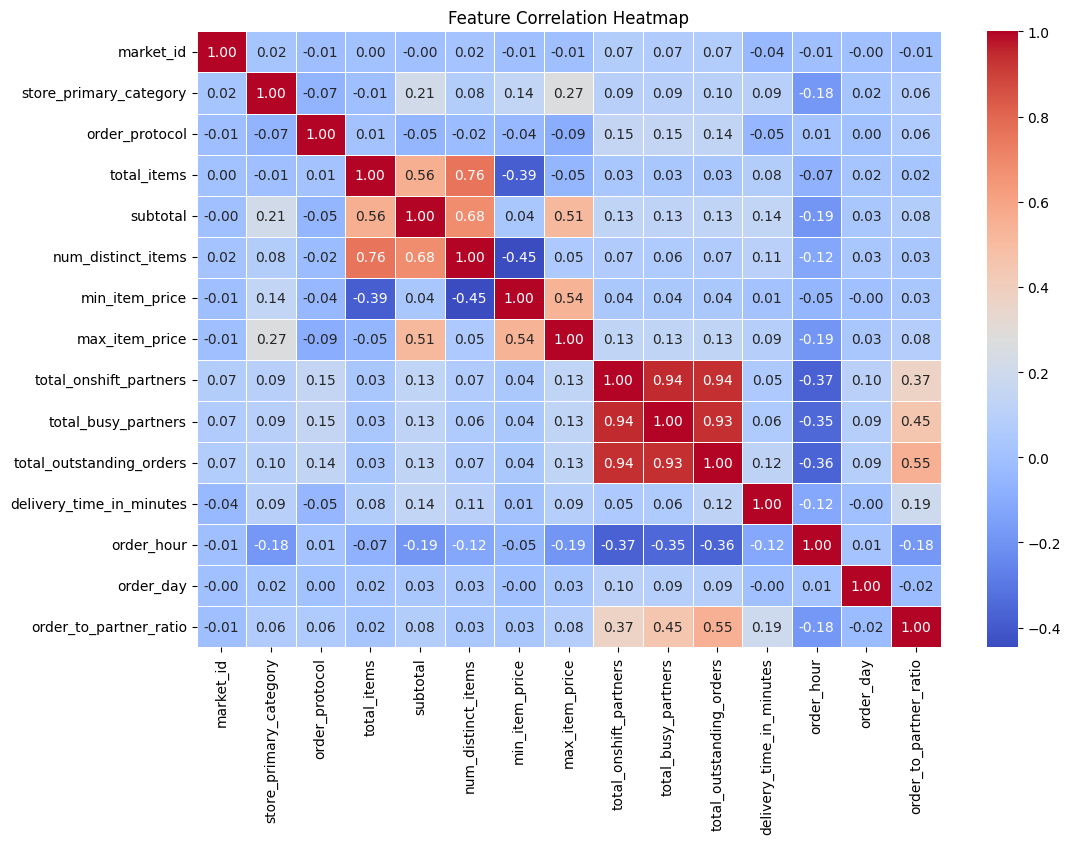

In [35]:
### Data Visualization
plt.figure(figsize=(12, 8))
corr_matrix = data.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()

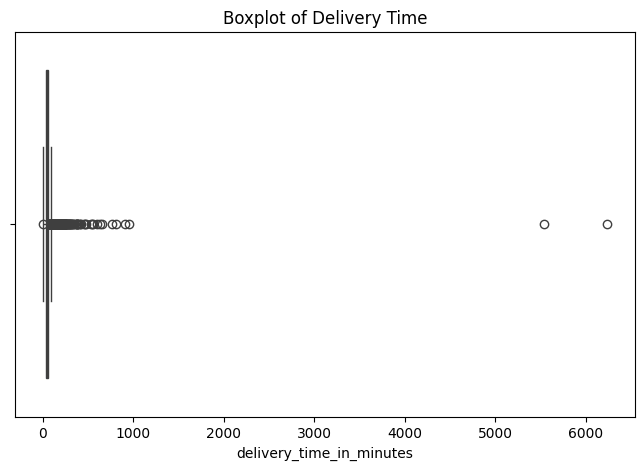

In [36]:
### Checking for outliers
plt.figure(figsize=(8, 5))
sns.boxplot(x=data['delivery_time_in_minutes'])
plt.title('Boxplot of Delivery Time')
plt.show()


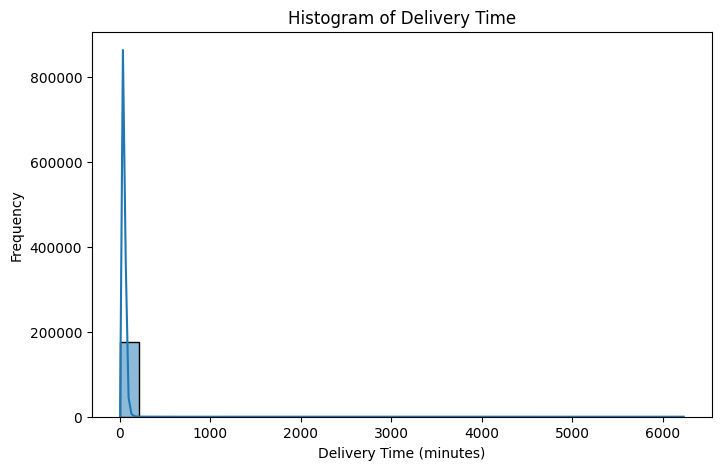

In [37]:
### Histogram of Delivery Time Distribution
plt.figure(figsize=(8, 5))
sns.histplot(data['delivery_time_in_minutes'], bins=30, kde=True)
plt.title('Histogram of Delivery Time')
plt.xlabel('Delivery Time (minutes)')
plt.ylabel('Frequency')
plt.show()

In [38]:
### Outlier handling using IQR and capping at upper bound
Q1 = data['delivery_time_in_minutes'].quantile(0.25)
Q3 = data['delivery_time_in_minutes'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

In [41]:
data['delivery_time_in_minutes'] = np.where(data['delivery_time_in_minutes'] > upper_bound, np.ceil(upper_bound), data['delivery_time_in_minutes'])

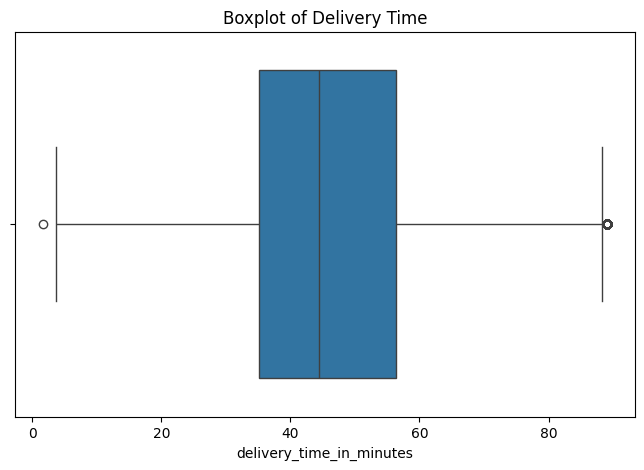

In [44]:
### Checking for outliers
plt.figure(figsize=(8, 5))
sns.boxplot(x=data['delivery_time_in_minutes'])
plt.title('Boxplot of Delivery Time')
plt.show()

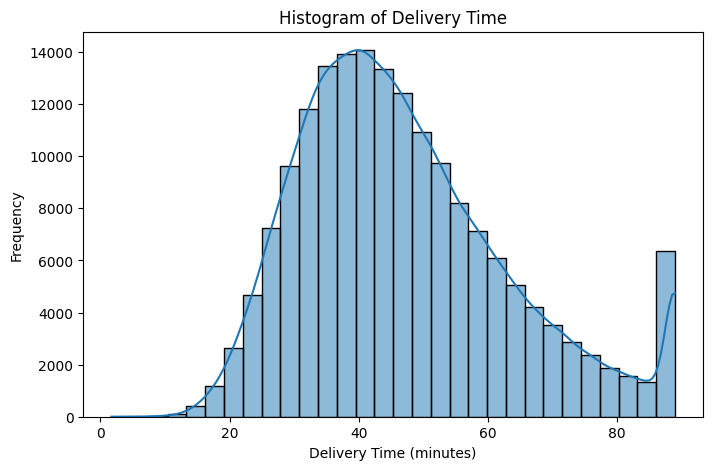

In [46]:
### Histogram of Delivery Time Distribution
plt.figure(figsize=(8, 5))
sns.histplot(data['delivery_time_in_minutes'], bins=30, kde=True)
plt.title('Histogram of Delivery Time')
plt.xlabel('Delivery Time (minutes)')
plt.ylabel('Frequency')
plt.show()

In [48]:

### Splitting data
X_train, X_test, y_train, y_test = train_test_split(X_poly, data['delivery_time_in_minutes'], test_size=0.2, random_state=42)

In [49]:
### Scaling the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train.astype(float))
X_test = scaler.transform(X_test.astype(float))


In [56]:
### Neural Network Model
def build_model():
    model = Sequential([
        Dense(128, input_shape=(X_train.shape[1],)),
        LeakyReLU(alpha=0.1),
        BatchNormalization(),
        Dropout(0.2),
        Dense(64),
        LeakyReLU(alpha=0.1),
        BatchNormalization(),
        Dropout(0.2),
        Dense(32),
        LeakyReLU(alpha=0.1),
        BatchNormalization(),
        Dense(1)
    ])
    optimizer = Adam(learning_rate=0.0003)
    model.compile(loss='mse', optimizer=optimizer, metrics=['mae', 'mse', 'mape','r2_score'])
    return model

In [58]:
### Train Model
model = build_model()
history = model.fit(X_train, y_train, epochs=300, validation_data=(X_test, y_test), batch_size=128, 
                    callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)])

C:\Users\VEERANNA\anaconda3\envs\py311\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
C:\Users\VEERANNA\anaconda3\envs\py311\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Epoch 1/300
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - loss: 2321.4854 - mae: 45.7960 - mape: 99.2066 - mse: 2321.4854 - r2_score: -7.7117 - val_loss: 1674.4858 - val_mae: 38.3752 - val_mape: 82.5600 - val_mse: 1674.4858 - val_r2_score: -5.2181
Epoch 2/300
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 1388.0350 - mae: 34.2064 - mape: 72.6121 - mse: 1388.0350 - r2_score: -4.1653 - val_loss: 610.6651 - val_mae: 20.6128 - val_mape: 40.4624 - val_mse: 610.6651 - val_r2_score: -1.2677
Epoch 3/300
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 477.9565 - mae: 17.3755 - mape: 33.7888 - mse: 477.9565 - r2_score: -0.7743 - val_loss: 227.4894 - val_mae: 11.2597 - val_mape: 23.6093 - val_mse: 227.4894 - val_r2_score: 0.1552
Epoch 4/300
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 217.4364 - mae: 11.1782 - mape: 24.4810 - mse: 217.4364 - r2_score: 0.1953 - val_loss: 198.8018 - val_mae: 10.9779 - val_mape: 25.7959 - val_mse: 198.8018 - val_r2_score: 0.2618
Epoch 5/300
1102/1102 ━━

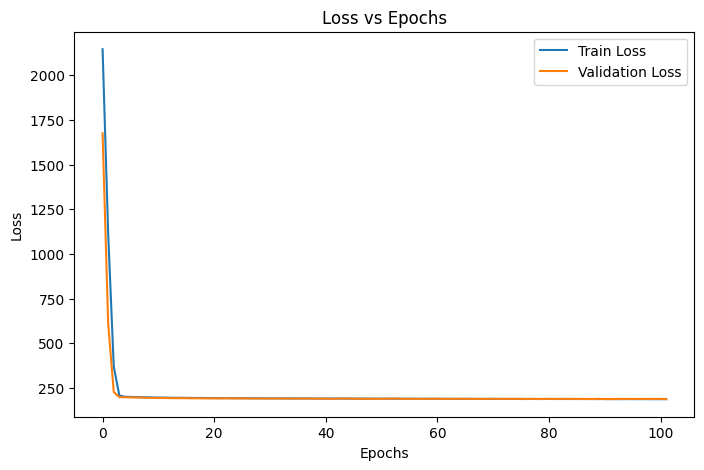

In [59]:
### Loss and Validation Loss vs Epoch Graph
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss vs Epochs')
plt.legend()
plt.show()

1102/1102 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
1102/1102 ━

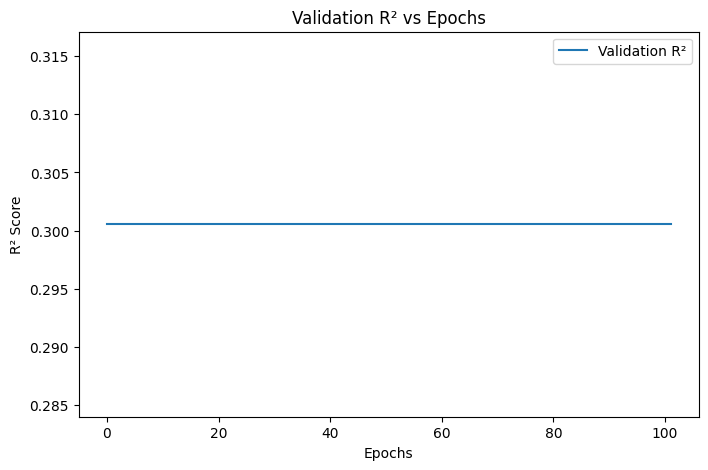

In [61]:
### Validation R² vs Epoch Graph
val_r2 = [r2_score(y_test, model.predict(X_test)) for _ in range(len(history.history['val_loss']))]

plt.figure(figsize=(8, 5))
plt.plot(val_r2, label='Validation R²')
plt.xlabel('Epochs')
plt.ylabel('R² Score')
plt.title('Validation R² vs Epochs')
plt.legend()
plt.show()


In [63]:
### Predictions and evaluation
y_pred = model.predict(X_test)
print("Neural Network Performance:")
print(f'MSE: {mean_squared_error(y_test, y_pred):.2f}')
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}')
print(f'MAE: {mean_absolute_error(y_test, y_pred):.2f}')
print(f'R2 Score: {r2_score(y_test, y_pred):.2f}')

1102/1102 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
Neural Network Performance:
MSE: 188.35
RMSE: 13.72
MAE: 10.72
R2 Score: 0.30
